In [1]:
from __future__ import annotations

from pathlib import Path
from datetime import datetime
import json
from typing import Any, Iterable
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from backend.sampling.masks import generate_observation_mask_hw
from backend.dataio.loader import load_raw
from backend.config.schemas import DataConfig

MASK_ROOT = Path("masks")
MASK_ROOT.mkdir(parents=True, exist_ok=True)

In [17]:
def build_and_save_mask(
    H: int,
    W: int,
    *,
    strategy: str = "random",
    mask_rate: float | None = None,
    mask_num: int | None = None,
    seed: int | None = 0,
    strategy_kwargs: dict[str, Any] | None = None,
    out_dir: str | Path = MASK_ROOT,
    mask_name: str | None = None,
    overwrite: bool = False,
) -> dict[str, Any]:
    if (mask_rate is None) == (mask_num is None):
        raise ValueError("mask_rate and mask_num must choose exactly one")

    out = Path(out_dir)
    out.mkdir(parents=True, exist_ok=True)

    mask_hw = generate_observation_mask_hw(
        H=H,
        W=W,
        mask_rate=mask_rate,
        mask_num=mask_num,
        seed=seed,
        strategy=strategy,
        strategy_kwargs=strategy_kwargs or {},
    )
    mask_hw = np.asarray(mask_hw, dtype=bool)

    obs_count = int(mask_hw.sum())
    density = float(obs_count) / float(H * W)

    if mask_name is None:
        rate_tag = "num" if mask_num is not None else "rate"
        rate_val = int(mask_num) if mask_num is not None else int(round(float(mask_rate) * 10000.0))
        seed_tag = -1 if seed is None else int(seed)
        stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        mask_name = f"{strategy}_H{H}_W{W}_{rate_tag}{rate_val}_seed{seed_tag}_{stamp}"

    csv_path = out / f"{mask_name}.csv"
    if csv_path.exists() and not overwrite:
        raise FileExistsError(f"File exists: {csv_path}")

    points = np.argwhere(mask_hw)
    points_df = pd.DataFrame(points, columns=["row", "col"])
    points_df.to_csv(csv_path, index=False, encoding="utf-8")

    meta = {
        "mask_name": mask_name,
        "shape": [int(H), int(W)],
        "strategy": str(strategy),
        "mask_rate": None if mask_rate is None else float(mask_rate),
        "mask_num": None if mask_num is None else int(mask_num),
        "seed": None if seed is None else int(seed),
        "strategy_kwargs": strategy_kwargs or {},
        "obs_count": obs_count,
        "density": density,
        "points_csv_path": str(csv_path),
    }

    return {
        "mask": mask_hw,
        "meta": meta,
        "path": csv_path,
    }

In [18]:
def load_mask_from_points_csv(
    mask_points_csv_path: str | Path,
    *,
    H: int,
    W: int,
) -> np.ndarray:
    path = Path(mask_points_csv_path)
    points = pd.read_csv(path)
    required = {"row", "col"}
    if not required.issubset(set(points.columns)):
        raise ValueError(f"CSV must contain columns {sorted(required)}")

    rows = points["row"].astype(int).to_numpy()
    cols = points["col"].astype(int).to_numpy()
    if rows.size != cols.size:
        raise ValueError("row/col column length mismatch")

    if rows.size > 0:
        if (rows < 0).any() or (rows >= int(H)).any() or (cols < 0).any() or (cols >= int(W)).any():
            raise ValueError(f"Point index out of bounds for shape {(H, W)}")

    mask_hw = np.zeros((int(H), int(W)), dtype=bool)
    mask_hw[rows, cols] = True
    return mask_hw


def save_mask_to_points_csv(
    mask_hw: np.ndarray,
    mask_points_csv_path: str | Path,
    *,
    overwrite: bool = True,
) -> Path:
    path = Path(mask_points_csv_path)
    if path.exists() and not overwrite:
        raise FileExistsError(f"File exists: {path}")

    mask = np.asarray(mask_hw, dtype=bool)
    if mask.ndim != 2:
        raise ValueError(f"mask_hw must be 2D [H,W], got {mask.shape}")

    points = np.argwhere(mask)
    pd.DataFrame(points, columns=["row", "col"]).to_csv(path, index=False, encoding="utf-8")
    return path

In [4]:
def load_cylinder2d_reference_frame(
    *,
    t_idx: int = 0,
    channel: int = 0,
    crop_h: int = 80,
    crop_w: int = 160,
    nc_path: str | Path = "data/cylinder2d.nc",
    var_keys: tuple[str, ...] = ("u", "v"),
) -> np.ndarray:
    cfg = DataConfig(
        source="netcdf",
        nc_path=Path(nc_path),
        var_keys=tuple(var_keys),
    )
    x_thwc = load_raw(cfg)
    t_max, h_max, w_max, c_max = x_thwc.shape

    if not (0 <= int(t_idx) < t_max):
        raise IndexError(f"t_idx out of range: {t_idx}, expected [0, {t_max - 1}]")
    if not (0 <= int(channel) < c_max):
        raise IndexError(f"channel out of range: {channel}, expected [0, {c_max - 1}]")
    if not (1 <= int(crop_h) <= h_max):
        raise ValueError(f"crop_h out of range: {crop_h}, expected [1, {h_max}]")
    if not (1 <= int(crop_w) <= w_max):
        raise ValueError(f"crop_w out of range: {crop_w}, expected [1, {w_max}]")

    frame = x_thwc[int(t_idx), : int(crop_h), : int(crop_w), int(channel)]
    return np.asarray(frame, dtype=np.float32)

In [19]:
def plot_mask_scatter(
    mask_hw: np.ndarray,
    *,
    background_hw: np.ndarray | None = None,
    title: str | None = None,
    figsize: tuple[float, float] | None = None,
    point_size: float = 20.0,
    point_edgecolor: str = "cyan",
    point_linewidth: float = 1.0,
    show_grid: bool = False,
) -> tuple[plt.Figure, plt.Axes]:
    mask = np.asarray(mask_hw, dtype=bool)
    if mask.ndim != 2:
        raise ValueError(f"mask_hw must be [H,W], got {mask.shape}")

    h, w = mask.shape
    points = np.argwhere(mask)
    rows = points[:, 0] if points.size else np.array([], dtype=int)
    cols = points[:, 1] if points.size else np.array([], dtype=int)

    if figsize is None:
        base_h = 4.0
        base_w = base_h * (float(w) / float(h))
        if background_hw is not None:
            base_w += 0.8
        figsize = (base_w, base_h)

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    if background_hw is not None:
        bg = np.asarray(background_hw, dtype=np.float32)
        if bg.shape != (h, w):
            raise ValueError(f"background shape mismatch: expected {(h, w)}, got {bg.shape}")
        im = ax.imshow(bg, cmap="viridis", origin="upper", interpolation="nearest", aspect="equal")
        fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    else:
        ax.set_facecolor("#111111")

    ax.scatter(
        cols,
        rows,
        s=float(point_size),
        facecolors="none",
        edgecolors=point_edgecolor,
        linewidths=float(point_linewidth),
    )
    ax.set_xlim(-0.5, w - 0.5)
    ax.set_ylim(h - 0.5, -0.5)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x / col")
    ax.set_ylabel("y / row")
    ax.set_title(title or f"Mask samples: {int(mask.sum())} points on {h}x{w}")
    if bool(show_grid):
        ax.grid(True, alpha=0.2)
    return fig, ax

In [6]:
def edit_mask_points(
    mask_hw: np.ndarray,
    *,
    add_points: Iterable[tuple[int, int]] | None = None,
    remove_points: Iterable[tuple[int, int]] | None = None,
    move_points: Iterable[tuple[tuple[int, int], tuple[int, int]]] | None = None,
    move_nearest: Iterable[tuple[tuple[int, int], tuple[int, int]]] | None = None,
    nearest_radius: float = 3.0,
    keep_count: bool = False,
) -> tuple[np.ndarray, dict[str, Any]]:
    mask = np.asarray(mask_hw, dtype=bool).copy()
    if mask.ndim != 2:
        raise ValueError(f"mask_hw must be [H,W], got {mask.shape}")
    h, w = mask.shape

    def _inside(p: tuple[int, int]) -> bool:
        r, c = int(p[0]), int(p[1])
        return 0 <= r < h and 0 <= c < w

    def _clip(p: tuple[int, int]) -> tuple[int, int]:
        r = int(np.clip(int(p[0]), 0, h - 1))
        c = int(np.clip(int(p[1]), 0, w - 1))
        return r, c

    before = int(mask.sum())
    report: dict[str, Any] = {
        "before_count": before,
        "added": [],
        "removed": [],
        "moved": [],
        "skipped": [],
    }

    for p in remove_points or []:
        r, c = _clip(p)
        if mask[r, c]:
            mask[r, c] = False
            report["removed"].append([r, c])
        else:
            report["skipped"].append({"op": "remove", "point": [r, c], "reason": "not_sampled"})

    for src, dst in move_points or []:
        sr, sc = _clip(src)
        dr, dc = _clip(dst)
        if not mask[sr, sc]:
            report["skipped"].append({"op": "move", "src": [sr, sc], "dst": [dr, dc], "reason": "src_not_sampled"})
            continue
        mask[sr, sc] = False
        mask[dr, dc] = True
        report["moved"].append([[sr, sc], [dr, dc]])

    for anchor, dst in move_nearest or []:
        ar, ac = _clip(anchor)
        dr, dc = _clip(dst)
        sampled = np.argwhere(mask)
        if sampled.size == 0:
            report["skipped"].append({"op": "move_nearest", "anchor": [ar, ac], "dst": [dr, dc], "reason": "empty_mask"})
            continue
        dist2 = (sampled[:, 0] - ar) ** 2 + (sampled[:, 1] - ac) ** 2
        idx = int(np.argmin(dist2))
        sr, sc = int(sampled[idx, 0]), int(sampled[idx, 1])
        if float(dist2[idx]) > float(nearest_radius) ** 2:
            report["skipped"].append({"op": "move_nearest", "anchor": [ar, ac], "dst": [dr, dc], "reason": "no_point_within_radius"})
            continue
        mask[sr, sc] = False
        mask[dr, dc] = True
        report["moved"].append([[sr, sc], [dr, dc]])

    for p in add_points or []:
        r, c = _clip(p)
        if not mask[r, c]:
            mask[r, c] = True
            report["added"].append([r, c])
        else:
            report["skipped"].append({"op": "add", "point": [r, c], "reason": "already_sampled"})

    after = int(mask.sum())
    if keep_count and after != before:
        diff = after - before
        sampled = np.argwhere(mask)
        if diff > 0:
            rng = np.random.RandomState(0)
            order = rng.permutation(sampled.shape[0])
            for idx in order[:diff].tolist():
                r, c = int(sampled[idx, 0]), int(sampled[idx, 1])
                if [r, c] in report["added"]:
                    continue
                mask[r, c] = False
                report["removed"].append([r, c])
        else:
            missing = -diff
            empty = np.argwhere(~mask)
            rng = np.random.RandomState(0)
            order = rng.permutation(empty.shape[0])
            for idx in order[:missing].tolist():
                r, c = int(empty[idx, 0]), int(empty[idx, 1])
                mask[r, c] = True
                report["added"].append([r, c])
        after = int(mask.sum())

    report["after_count"] = after
    report["delta"] = after - before
    return mask, report

In [7]:
def apply_csv_edit_plan(
    mask_hw: np.ndarray,
    plan_csv_path: str | Path,
    *,
    keep_count: bool = True,
) -> tuple[np.ndarray, dict[str, Any]]:
    plan = pd.read_csv(plan_csv_path)
    required = {"op", "row", "col"}
    if not required.issubset(set(plan.columns)):
        raise ValueError(f"CSV must contain columns {sorted(required)}")

    add_points: list[tuple[int, int]] = []
    remove_points: list[tuple[int, int]] = []
    move_points: list[tuple[tuple[int, int], tuple[int, int]]] = []

    for _, row in plan.iterrows():
        op = str(row["op"]).strip().lower()
        r = int(row["row"]); c = int(row["col"])
        if op == "add":
            add_points.append((r, c))
        elif op == "remove":
            remove_points.append((r, c))
        elif op == "move":
            if "src_row" not in plan.columns or "src_col" not in plan.columns:
                raise ValueError("move op requires src_row, src_col columns")
            sr = int(row["src_row"]); sc = int(row["src_col"])
            move_points.append(((sr, sc), (r, c)))
        else:
            raise ValueError(f"Unsupported op: {op}")

    return edit_mask_points(
        mask_hw,
        add_points=add_points,
        remove_points=remove_points,
        move_points=move_points,
        keep_count=keep_count,
    )

In [25]:
# 调试 1: 生成并存盘（单文件 CSV）
pack = build_and_save_mask(
    H=80,
    W=160,
    strategy="structure_aware",
    mask_num=10,
    seed=7,
    strategy_kwargs={
        "importance_mix": 0.65,
        "skeleton_points": 16,
        "region_bounds_frac": (0.15, 0.5),
        "region_ratios": {"left": 0.35, "middle": 0.35, "right": 0.2, "global_random": 0.1},
    },
    out_dir="masks",
    mask_name="cyl80x160_sa_num10_seed7",
    overwrite=True,
 )

print(pack["meta"])

{'mask_name': 'cyl80x160_sa_num10_seed7', 'shape': [80, 160], 'strategy': 'structure_aware', 'mask_rate': None, 'mask_num': 10, 'seed': 7, 'strategy_kwargs': {'importance_mix': 0.65, 'skeleton_points': 16, 'region_bounds_frac': (0.15, 0.5), 'region_ratios': {'left': 0.35, 'middle': 0.35, 'right': 0.2, 'global_random': 0.1}}, 'obs_count': 10, 'density': 0.00078125, 'points_csv_path': 'masks/cyl80x160_sa_num10_seed7.csv'}


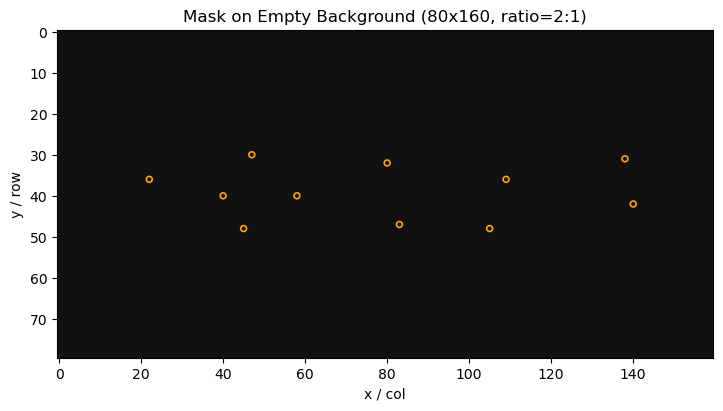

In [93]:
# 调试 2: 空底图可视化（空心散点，严格保持像素比例）
mask_hw = load_mask_from_points_csv("masks/cylinder2d-80-160-mask1.csv", H=80, W=160)
_ = plot_mask_scatter(
    mask_hw,
    background_hw=None,
    title="Mask on Empty Background (80x160, ratio=2:1)",
    point_size=18,
    point_edgecolor="orange",
    point_linewidth=1.2,
    show_grid=False,
 )
plt.show()

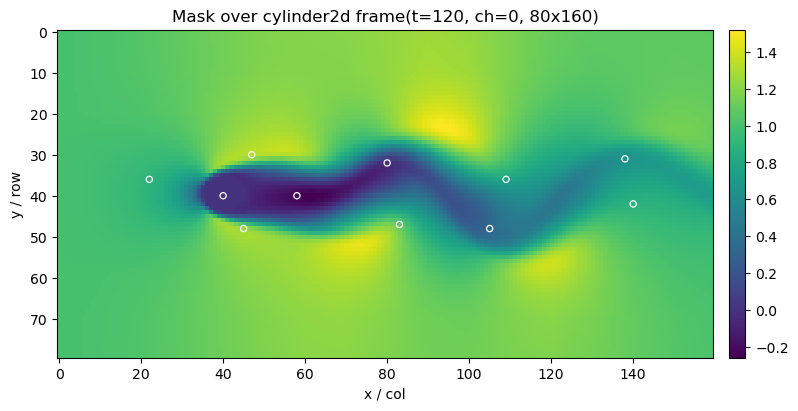

In [91]:
# 调试 3: 参考底图可视化（cylinder2d 指定时刻 + 指定通道 + 裁切）
bg = load_cylinder2d_reference_frame(
    t_idx=350,
    channel=0,
    crop_h=80,
    crop_w=160,
    nc_path="data/cylinder2d.nc",
    var_keys=("u", "v"),
)

_ = plot_mask_scatter(
    mask_hw,
    background_hw=bg,
    title="Mask over cylinder2d frame(t=120, ch=0, 80x160)",
    point_size=20,
    point_edgecolor="white",
    point_linewidth=0.9,
    show_grid=False,
 )
plt.show()

{'before_count': 640, 'added': [[20, 20]], 'removed': [[28, 21]], 'moved': [[[35, 49], [35, 58]], [[38, 72], [40, 80]]], 'skipped': [{'op': 'remove', 'point': [10, 10], 'reason': 'not_sampled'}], 'after_count': 640, 'delta': 0}


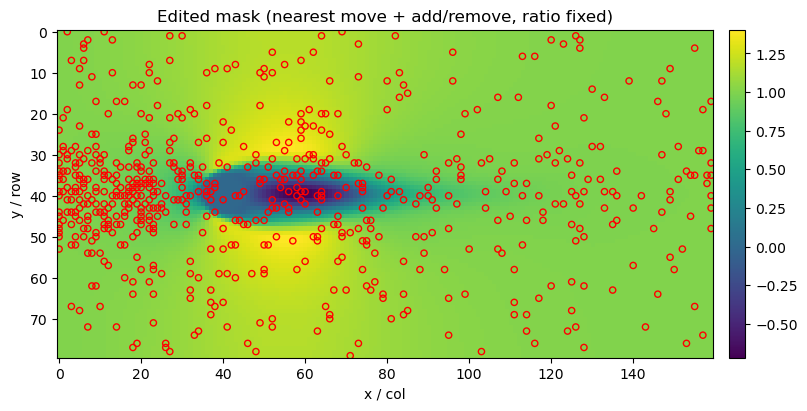

{'before_count': 640, 'added': [[25, 25], [47, 143]], 'removed': [[20, 20]], 'moved': [[[35, 58], [35, 62]]], 'skipped': [], 'after_count': 640, 'delta': 0}


PosixPath('masks/cyl80x160_sa_num640_seed7_edited.csv')

In [23]:
# 调试 4: 高效改点方案（move_nearest + CSV 批量）
edited_mask, report = edit_mask_points(
    mask_hw,
    move_nearest=[((35, 50), (35, 58)), ((40, 72), (40, 80))],
    add_points=[(20, 20)],
    remove_points=[(10, 10)],
    nearest_radius=6.0,
    keep_count=True,
 )
print(report)

_ = plot_mask_scatter(
    edited_mask,
    background_hw=bg,
    title="Edited mask (nearest move + add/remove, ratio fixed)",
    point_size=20,
    point_edgecolor="red",
    point_linewidth=1.0,
 )
plt.show()

# CSV 批量编辑模板（手工改这个 CSV 再应用）
plan_csv = Path("masks/edit_plan_example.csv")
pd.DataFrame(
    [
        {"op": "move", "src_row": 35, "src_col": 58, "row": 35, "col": 62},
        {"op": "add", "row": 25, "col": 25},
        {"op": "remove", "row": 20, "col": 20},
    ]
).to_csv(plan_csv, index=False, encoding="utf-8")

edited_mask_v2, report_v2 = apply_csv_edit_plan(edited_mask, plan_csv, keep_count=True)
print(report_v2)

save_mask_to_points_csv(edited_mask_v2, "masks/cyl80x160_sa_num640_seed7_edited.csv", overwrite=True)